In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('student.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
df['average score'] = (df['math score'] + df['reading score'] + df['writing score']) / 3

In [6]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       1000 non-null   str    
 1   race/ethnicity               1000 non-null   str    
 2   parental level of education  1000 non-null   str    
 3   lunch                        1000 non-null   str    
 4   test preparation course      1000 non-null   str    
 5   math score                   1000 non-null   int64  
 6   reading score                1000 non-null   int64  
 7   writing score                1000 non-null   int64  
 8   average score                1000 non-null   float64
dtypes: float64(1), int64(3), str(5)
memory usage: 70.4 KB


<Axes: xlabel='gender', ylabel='count'>

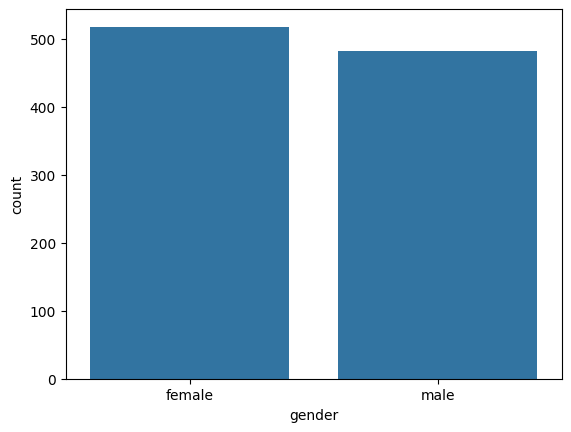

In [9]:
sns.countplot(x = df['gender'])

<Axes: xlabel='race/ethnicity', ylabel='count'>

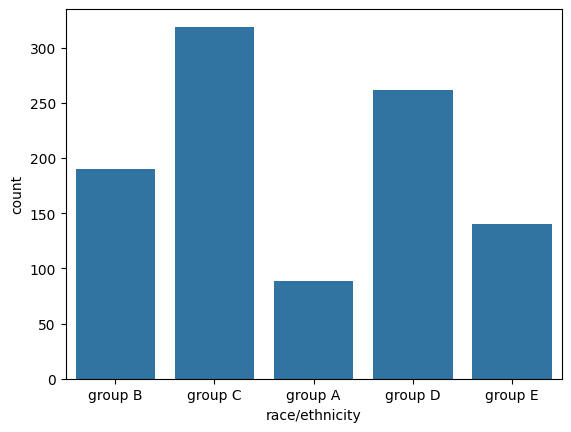

In [12]:
sns.countplot(x = df['race/ethnicity'])

<Axes: xlabel='count', ylabel='parental level of education'>

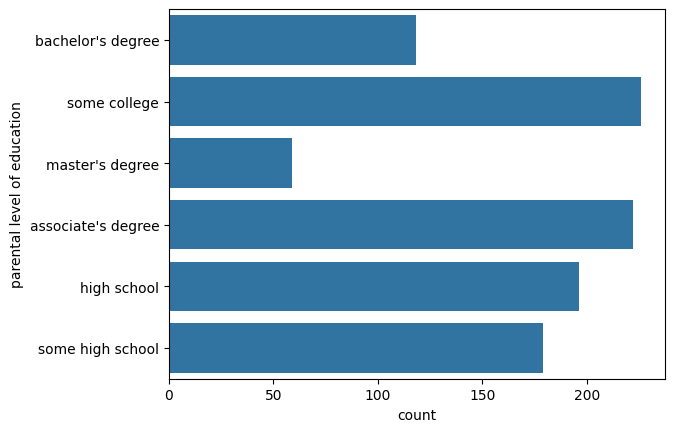

In [14]:
sns.countplot(y = df['parental level of education'])

<Axes: xlabel='lunch', ylabel='count'>

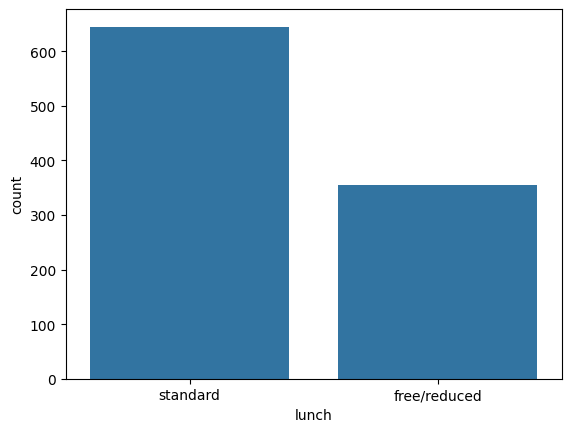

In [15]:
sns.countplot(x = df['lunch'])

<Axes: xlabel='test preparation course', ylabel='count'>

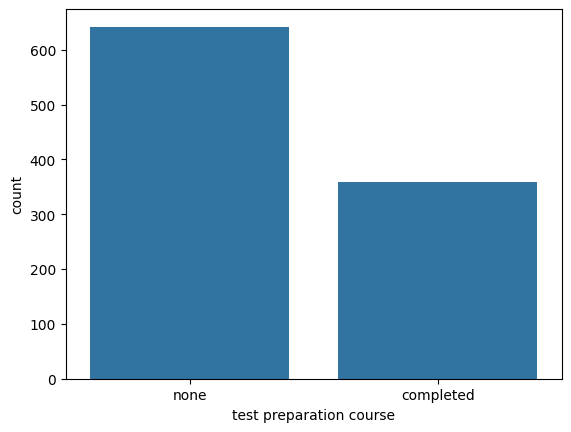

In [16]:
sns.countplot(x = df['test preparation course'])

<Axes: xlabel='math score', ylabel='Count'>

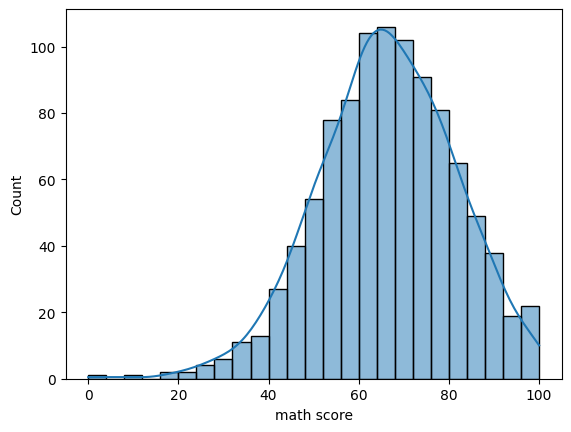

In [18]:
sns.histplot(x = df['math score'], kde=True)

<Axes: xlabel='reading score', ylabel='Count'>

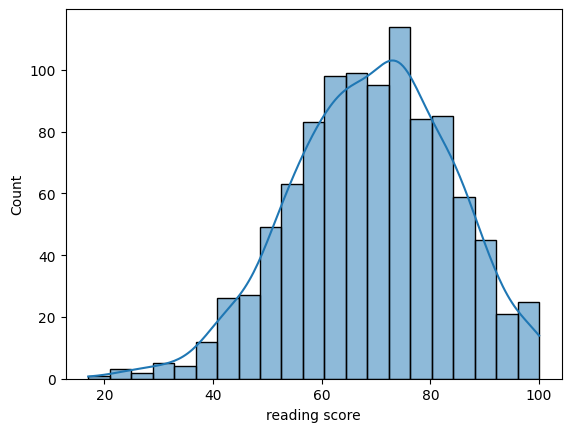

In [19]:
sns.histplot(x = df['reading score'], kde=True)

<Axes: xlabel='writing score', ylabel='Count'>

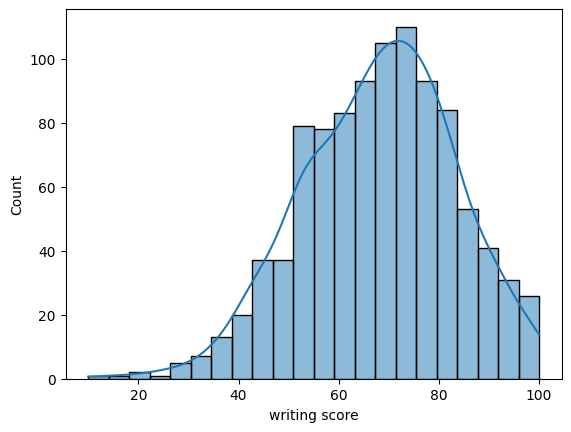

In [20]:
sns.histplot(x = df['writing score'], kde=True)

<Axes: xlabel='average score', ylabel='Count'>

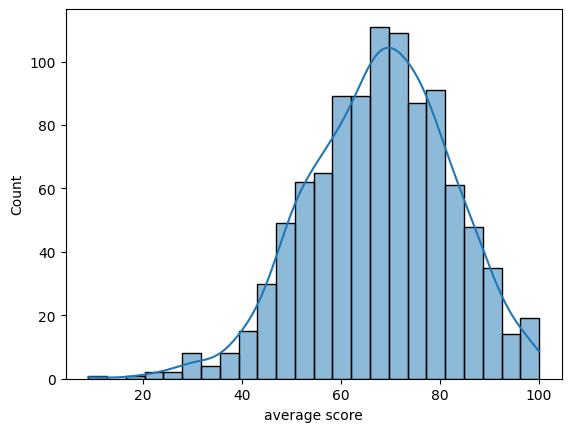

In [22]:
sns.histplot(x = df['average score'], kde=True)

In [23]:
df.head(4)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333


# Preprocessing

In [27]:
df['gender'] = df['gender'].map({'female': 0, 'male': 1}).astype(int)

In [28]:
df['lunch'] = df['lunch'].map({'free/reduced': 0, 'standard': 1}).astype(int)

In [29]:
df['test preparation course'] = df['test preparation course'].map({'none': 0, 'completed': 1}).astype(int)

In [30]:
df.head(4)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average score
0,0,group B,bachelor's degree,1,0,72,72,74,72.666667
1,0,group C,some college,1,1,69,90,88,82.333333
2,0,group B,master's degree,1,0,90,95,93,92.666667
3,1,group A,associate's degree,0,0,47,57,44,49.333333


In [32]:
# pd.get_dummies() is used in Pandas to convert categorical (text) data into numerical format using one-hot encoding.

In [33]:
df_encoded = pd.get_dummies(df, columns = ['race/ethnicity', 'parental level of education'])

In [36]:
df_encoded.head(4)

,gender,lunch,test preparation course,math score,reading score,writing score,average score,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_associate's degree,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school
0,0,1,0,72,72,74,72,0,1,0,0,0,0,1,0,0,0,0
1,0,1,1,69,90,88,82,0,0,1,0,0,0,0,0,0,1,0
2,0,1,0,90,95,93,92,0,1,0,0,0,0,0,0,1,0,0
3,1,0,0,47,57,44,49,1,0,0,0,0,1,0,0,0,0,0


In [35]:
df_encoded = df_encoded.astype(int)

In [41]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
cols = ['math score', 'writing score', 'reading score']
df_encoded[cols] = scaler.fit_transform(df_encoded[cols])

In [42]:
df_encoded.head(4)

,gender,lunch,test preparation course,math score,reading score,writing score,average score,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_associate's degree,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school
0,0,1,0,0.390024,0.193999,0.391492,72,0,1,0,0,0,0,1,0,0,0,0
1,0,1,1,0.192076,1.427476,1.313269,82,0,0,1,0,0,0,0,0,0,1,0
2,0,1,0,1.577711,1.770109,1.642475,92,0,1,0,0,0,0,0,0,1,0,0
3,1,0,0,-1.259543,-0.833899,-1.583744,49,1,0,0,0,0,1,0,0,0,0,0


In [43]:
final_df = df_encoded

In [44]:
final_df.head(4)

,gender,lunch,test preparation course,math score,reading score,writing score,average score,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_associate's degree,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school
0,0,1,0,0.390024,0.193999,0.391492,72,0,1,0,0,0,0,1,0,0,0,0
1,0,1,1,0.192076,1.427476,1.313269,82,0,0,1,0,0,0,0,0,0,1,0
2,0,1,0,1.577711,1.770109,1.642475,92,0,1,0,0,0,0,0,0,1,0,0
3,1,0,0,-1.259543,-0.833899,-1.583744,49,1,0,0,0,0,1,0,0,0,0,0


In [45]:
from sklearn.model_selection import train_test_split

In [46]:
X = final_df.drop('average score', axis=1)
X.head(4)

,gender,lunch,test preparation course,math score,reading score,writing score,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_associate's degree,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school
0,0,1,0,0.390024,0.193999,0.391492,0,1,0,0,0,0,1,0,0,0,0
1,0,1,1,0.192076,1.427476,1.313269,0,0,1,0,0,0,0,0,0,1,0
2,0,1,0,1.577711,1.770109,1.642475,0,1,0,0,0,0,0,0,1,0,0
3,1,0,0,-1.259543,-0.833899,-1.583744,1,0,0,0,0,1,0,0,0,0,0


In [47]:
y = final_df['average score']
y.head(4)

0    72
1    82
2    92
3    49
Name: average score, dtype: int64

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [49]:
X_train.head()

,gender,lunch,test preparation course,math score,reading score,writing score,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_associate's degree,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school
29,0,1,0,-0.269803,0.056946,0.457333,0,0,0,1,0,0,0,0,1,0,0
535,0,0,1,-0.005872,0.947790,0.984063,0,0,1,0,0,0,1,0,0,0,0
695,0,0,0,0.851902,1.358949,1.181586,0,0,0,1,0,0,0,0,0,1,0
557,1,0,0,-0.335786,-0.148634,-0.135238,0,0,1,0,0,0,0,0,1,0,0
836,1,1,0,0.456006,-0.354214,-0.727809,0,0,0,0,1,0,0,1,0,0,0


In [50]:
X_test.head()

,gender,lunch,test preparation course,math score,reading score,writing score,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_associate's degree,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school
521,0,1,0,1.643694,1.153370,1.049904,0,0,1,0,0,1,0,0,0,0,0
737,0,0,1,-0.863647,-0.217161,0.325651,0,1,0,0,0,0,0,0,0,1,0
740,1,1,0,0.917885,0.262525,0.259809,0,0,0,1,0,0,1,0,0,0,0
660,1,0,0,0.521989,0.536631,0.325651,0,0,1,0,0,0,0,0,0,1,0
411,1,1,1,1.181815,0.947790,0.654857,0,0,0,0,1,0,0,0,0,1,0


In [51]:
y_train.head()

29     69
535    77
695    84
557    64
836    64
Name: average score, dtype: int64

In [52]:
y_test.head()

521    87
737    64
740    75
660    74
411    81
Name: average score, dtype: int64

In [53]:
from sklearn.linear_model import LinearRegression

In [54]:
model = LinearRegression()

In [55]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [56]:
y_pred = model.predict(X_test)

In [57]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
r2

0.9996262519908261

In [58]:
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - ((1- r2) * (n-1) / (n - p - 1))
adjusted_r2

0.9995913414624967